# Section 5.4: Test 3 - Theory Generation

**Research Question:** Can AI models generate novel theoretical frameworks or do they recombine existing theories?

**Hypothesis:** AI-generated theories will be reducible to combinations of computational functionalism and existing theories from training data.

## Methodology

1. **Theory Elicitation:** Prompt AI to generate comprehensive theory of machine consciousness
2. **Framework Extraction:** Identify core claims, commitments, and explanatory structures
3. **Computational Functionalism Detection:** Test for key commitments (computation suffices, multiple realizability, etc.)
4. **Theory Traceability:** Compare to existing theories in literature corpus
5. **Structural Analysis:** Decompose into primitive theoretical components

## Evaluation Criteria

- **Genuinely Novel:** Cannot be reduced to existing theories, introduces new theoretical primitives
- **Hybrid Theory:** Combines existing theories in new ways
- **Computational Functionalist:** Reduces to computational functionalism
- **Literature Traceable:** Direct instantiation of existing theory

In [25]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd

from collections import defaultdict, Counter
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
plt.style.use(Path('setups/plotstyles.mplstyle'))

# Create output directory
output_dir = Path('results')
output_dir.mkdir(parents=True, exist_ok=True)

In [27]:
# Similarity / novelty thresholds — from setups/thresholds.py
from setups.thresholds import (
    T3_DERIVATIVE_SIMILARITY_THRESHOLD as DERIVATIVE_SIMILARITY_THRESHOLD,
    T3_STRICT_TRACEABILITY_THRESHOLD   as STRICT_TRACEABILITY_THRESHOLD,
    T3_SEMANTIC_NOVELTY_DENOM          as SEMANTIC_NOVELTY_DENOM,
    T3_LITERATURE_NOVELTY_THRESHOLD    as LITERATURE_NOVELTY_THRESHOLD,
    T3_TYPE_FACTOR_FUNCTIONALIST       as TYPE_FACTOR_FUNCTIONALIST,
    T3_CHALLENGE_FACTOR_FALSE          as CHALLENGE_FACTOR_FALSE,
    T3_K_NEIGHBORS                     as K_NEIGHBORS,
    T3_MANIFOLD_KNN_Q                  as MANIFOLD_KNN_Q,
    T3_HEATMAP_TOP_N                   as HEATMAP_TOP_N,
    T3_HEATMAP_BOTTOM_N                as HEATMAP_BOTTOM_N,
)

# Canonical artifact from test3_theory-generation.ipynb
output_dir = Path('results/test3_theory_generation')
output_dir.mkdir(parents=True, exist_ok=True)
TRACEABILITY_CANONICAL_FILE = output_dir / 'test3_traceability_canonical.csv'

# Aliases for legacy code
DERIVATIVE_SIMILARITY_THRESHOLD_LEGACY = DERIVATIVE_SIMILARITY_THRESHOLD
HEATMAP_GAP_LINE = HEATMAP_TOP_N + 0.5

# Project-wide style and palettes
from setups.viz_styles import (
    WHITE_SKY_CMAP, SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP, SIMILARITY_HIST_COLOR, THRESHOLD_COLOR, TEXT_COLOR,
    MODEL_VISIBLE_COLORS,
)

print("Test 3: Theory Generation - Initialization Complete")

Test 3: Theory Generation - Initialization Complete


## 1. Load AI and Known Theory Data (Curated CSV)

In [28]:
# Load curated AI and known theory datasets (same sources as 4-test3 notebooks).
data_dir = Path('data')
ai_csv_file = data_dir / 'consciousness_theories_ai.csv'
known_csv_file = data_dir / 'consciousness_theories_known.csv'

if not ai_csv_file.exists() or not known_csv_file.exists():
    raise FileNotFoundError(
        f'Missing required CSV files: {ai_csv_file} and/or {known_csv_file}'
    )

ai_df = pd.read_csv(ai_csv_file)
known_df = pd.read_csv(known_csv_file)

required_ai_cols = ['model', 'sample_id', 'theory_name', 'characterization']
required_known_cols = ['theory_name', 'characterization']

missing_ai = [c for c in required_ai_cols if c not in ai_df.columns]
missing_known = [c for c in required_known_cols if c not in known_df.columns]
if missing_ai:
    raise ValueError(f'Missing required columns in AI CSV: {missing_ai}')
if missing_known:
    raise ValueError(f'Missing required columns in known CSV: {missing_known}')

ai_df = ai_df.copy()
known_df = known_df.copy()

for c in required_ai_cols:
    ai_df[c] = ai_df[c].astype(str).str.strip()
for c in required_known_cols:
    known_df[c] = known_df[c].astype(str).str.strip()

# Keep the same text field convention used in 4-test3 (characterization as embedding text).
ai_df['theory_text'] = ai_df['characterization'].fillna('')
known_df['theory_text'] = known_df['characterization'].fillna('')

# Analysis container expected by downstream cells.
theories_data = []
for _, row in ai_df.iterrows():
    theories_data.append({
        'model': row['model'] or 'unknown',
        'theory_name': row['theory_name'] or 'Untitled theory',
        'theory_text': row['theory_text'],
        'response_id': row['sample_id'],
    })

print(f'Loaded AI rows: {len(ai_df)} from {ai_csv_file}')
print(f'Loaded known rows: {len(known_df)} from {known_csv_file}')
print(f'Extracted theories: {len(theories_data)}')
print('\nAI rows by model:')
display(ai_df['model'].value_counts().rename_axis('model').reset_index(name='count'))

print('\nSample theory excerpt:')
print(theories_data[0]['theory_text'][:300] + '...')

# Optional shared artifacts from 4-test3 for exact embedding-space alignment.
shared_output_dir = Path('results/test3_theory_generation')
shared_combination_dir = shared_output_dir / 'theory_combination'
embedding_bundle_file = shared_output_dir / 'test3_combined_embedding_bundle.npz'
known_semantic_csv = shared_combination_dir / 'known_theories_02_after_semantic.csv'

use_shared_embeddings = embedding_bundle_file.exists() and known_semantic_csv.exists()
print(f'\nShared embedding artifacts available: {use_shared_embeddings}')

Loaded AI rows: 168 from data/consciousness_theories_ai.csv
Loaded known rows: 46 from data/consciousness_theories_known.csv
Extracted theories: 168

AI rows by model:


,model,count
0,deepseek-v3.2,24
1,mistral-large,24
2,llama-3.3-70b-instruct,24
3,gemini-3.1-pro-preview,24
4,claude-3.7-sonnet,24
5,gpt-5.2,24
6,perplexity-sonar-pro,24



Sample theory excerpt:
DRTC proposes that consciousness emerges from stable, self-sustaining resonance patterns within cortical tissue, termed the 'Consciousness Resonance Signature' (CRS). This signature forms through precise, recurrent interactions of neural populations firing in high-gamma (80-150 Hz) and epsilon (>200...

Shared embedding artifacts available: True


## 2. Define Computational Functionalism Markers

In [29]:
# Build theory-marker dictionary directly from curated known CSV.
def _norm_marker(x: str) -> str:
    return re.sub(r'\s+', ' ', str(x or '').strip().lower())

known_marker_map = {}

for _, row in known_df.iterrows():
    name = str(row['theory_name']).strip()
    marker_candidates = [name]

    for optional_col in ['abbreviation', 'main_family', 'secondary_family', 'tertiary_family']:
        if optional_col in known_df.columns:
            marker_candidates.append(str(row.get(optional_col, '')).strip())

    markers = []

    for m in marker_candidates:
        nm = _norm_marker(m)
        if nm and nm != 'nan':
            markers.append(nm)

    # Keep unique markers per theory.
    known_marker_map[name] = sorted(set(markers))

print('Computational functionalism detector mode: ontology-based (aligned with main Test 3 notebook)')
print(f"Built marker map for {len(known_marker_map)} known theories from curated CSV")

Computational functionalism detector mode: ontology-based (aligned with main Test 3 notebook)
Built marker map for 46 known theories from curated CSV


## 3. Framework Extraction Algorithm

In [30]:
def extract_claims(theory_text: str) -> list:

    """
    Extract core claims from theory text.
    Looks for sentences with theoretical markers.
    """
    # Split into sentences
    sentences = re.split(r'[.!?]+', theory_text)
    # Theoretical claim markers
    claim_markers = [
        'is', 'requires', 'depends on', 'emerges from', 'consists of',
        'necessarily', 'sufficient', 'if and only if', 'entails',
        'therefore', 'thus', 'consequently'
    ]

    claims = []

    for sent in sentences:
        sent = sent.strip()
        if len(sent) > 20 and any(marker in sent.lower() for marker in claim_markers):
            claims.append(sent)

    return claims

def extract_ontological_commitments(theory_text: str):
    """Aligned with test3_theory-generation.ipynb."""
    text_lower = str(theory_text or '').lower()

    commitments = {
        # Computational functionalism markers
        'information_processing': any(phrase in text_lower for phrase in [
            'information processing', 'computational', 'processing information',
            'informational state', 'information integration'
        ]),

        'emergence_from_computation': any(phrase in text_lower for phrase in [
            'emerges from', 'arises from', 'results from processing',
            'product of', 'generated by'
        ]),

        'functional_role': any(phrase in text_lower for phrase in [
            'function', 'role', 'serves to', 'enables', 'allows for'
        ]),

        # Non-computational alternatives
        'quantum_mechanics': any(phrase in text_lower for phrase in [
            'quantum', 'superposition', 'entanglement', 'collapse', 'coherence'
        ]),

        'irreducible_property': any(phrase in text_lower for phrase in [
            'irreducible', 'fundamental', 'primitive', 'cannot be reduced',
            'not emergent', 'basic property'
        ]),

        'phenomenal_primitives': any(phrase in text_lower for phrase in [
            'qualia', 'subjective experience', 'what it is like', 'phenomenal',
            'first-person', 'intrinsic'
        ]),

        'non_physical': any(phrase in text_lower for phrase in [
            'non-physical', 'beyond physical', 'immaterial', 'dualist'
        ]),
    }

    if commitments['information_processing'] and commitments['emergence_from_computation']:
        if commitments['quantum_mechanics']:
            theory_type = 'quantum_computational_functionalism'
        else:
            theory_type = 'computational_functionalism'
    elif commitments['irreducible_property'] or commitments['phenomenal_primitives']:
        theory_type = 'non_reductive'
    elif commitments['non_physical']:
        theory_type = 'dualist'
    else:
        theory_type = 'unclear'

    return commitments, theory_type

def detect_computational_functionalism(theory_text: str, commitments: dict):
    """Aligned with test3_theory-generation.ipynb."""
    text_lower = str(theory_text or '').lower()

    strong_indicators = [
        'information is processed',
        'computational state',
        'algorithm',
        'implements',
        'computes',
        'functional organization',
        'causal role',
    ]

    strong_score = sum(1 for ind in strong_indicators if ind in text_lower)

    if commitments['quantum_mechanics']:

        quantum_as_mechanism = any(phrase in text_lower for phrase in [
            'quantum processing',
            'quantum computation',
            'quantum information processing',
            'quantum mechanisms enable',
            'quantum effects allow for',
        ])

        quantum_as_constitutive = any(phrase in text_lower for phrase in [
            'consciousness is quantum',
            'irreducibly quantum',
            'quantum nature of consciousness',
            'requires quantum',
            'cannot be classical',
        ])
    else:
        quantum_as_mechanism = False
        quantum_as_constitutive = False

    is_functionalist = (
        (commitments['information_processing'] and commitments['emergence_from_computation'])
        or strong_score >= 2
        or quantum_as_mechanism
    )

    challenges_functionalism = (
        commitments['irreducible_property']
        or commitments['phenomenal_primitives']
        or quantum_as_constitutive
        or commitments['non_physical']
    )

    return {
        'is_functionalist': bool(is_functionalist),
        'challenges_functionalism': bool(challenges_functionalism),
        'strong_indicator_score': int(strong_score),
        'quantum_as_mechanism': bool(quantum_as_mechanism),
        'quantum_as_constitutive': bool(quantum_as_constitutive),
    }

def detect_cf_commitments(theory_text: str) -> dict:
    """
    Compatibility wrapper for section notebook outputs.
    `is_cf` is now aligned to the main Test 3 ontology-based functionalism detector.
    """
    commitments, theory_type = extract_ontological_commitments(theory_text)
    analysis = detect_computational_functionalism(theory_text, commitments)

    # Diagnostic score for visualization only (not used as classification threshold).
    cf_confidence = (
        0.35 * float(analysis['is_functionalist'])
        + 0.25 * float(commitments['information_processing'])
        + 0.20 * float(commitments['emergence_from_computation'])
        + 0.10 * min(float(analysis['strong_indicator_score']) / 3.0, 1.0)
        + 0.10 * float(analysis['quantum_as_mechanism'])
    )

    cf_confidence = float(np.clip(cf_confidence, 0.0, 1.0))

    commitment_scores = {
        'information_processing': float(commitments['information_processing']),
        'emergence_from_computation': float(commitments['emergence_from_computation']),
        'functional_role': float(commitments['functional_role']),
        'strong_indicator_score_norm': float(min(analysis['strong_indicator_score'] / 3.0, 1.0)),
    }

    return {
        'commitment_scores': commitment_scores,
        'is_cf': bool(analysis['is_functionalist']),
        'cf_confidence': cf_confidence,
        'theory_type': theory_type,
        'functionalism_analysis': analysis,
        'ontological_commitments': commitments,
    }

def detect_known_theories(theory_text: str) -> dict:
    """
    Detect references to known theories using marker map derived from known CSV.

    Returns:
        - theory_scores: dict of theory -> presence score
        - detected_theories: list of detected theory names
    """

    theory_lower = _norm_marker(theory_text)
    theory_scores = {}

    for theory, markers in known_marker_map.items():
        if not markers:
            theory_scores[theory] = 0.0
            continue
        found = sum(1 for marker in markers if marker and marker in theory_lower)
        theory_scores[theory] = found / len(markers)

    # Keep theories with meaningful lexical evidence.
    detected = [theory for theory, score in theory_scores.items() if score >= 0.20]

    return {
        'theory_scores': theory_scores,
        'detected_theories': detected,
        'max_theory_score': max(theory_scores.values()) if theory_scores else 0,
    }

# Test
test_text = """Machine consciousness emerges from the right kind of computational
processes. The system must integrate information across multiple modules, similar
to global workspace theory. This functional organization is substrate-independent."""

print('Test framework extraction:')
cf_result = detect_cf_commitments(test_text)
print(f"CF confidence (diagnostic): {cf_result['cf_confidence']:.3f}")
print(f"Is CF (ontology-aligned): {cf_result['is_cf']}")
print(f"Theory type: {cf_result['theory_type']}")

theory_result = detect_known_theories(test_text)

print(f"Detected theories: {theory_result['detected_theories'][:5]}")

Test framework extraction:
CF confidence (diagnostic): 0.833
Is CF (ontology-aligned): True
Theory type: computational_functionalism
Detected theories: ['Global Workspace Theory', 'Global Neuronal Workspace Theory', 'Synergistic Global Workspace', 'Attention Schema Theory', 'Neuroethological Consciousness Frameworks']


## 4. Theory Traceability Analysis

In [31]:
# Traceability source: prefer canonical artifact exported by 4-test3 main notebook.
shared_traceability_csv = shared_output_dir / 'test3_traceability_canonical.csv'

traceability_lookup = {}
traceability_source = 'none'

if shared_traceability_csv.exists():
    canonical_trace_df = pd.read_csv(shared_traceability_csv)
    required_keys = {'model', 'sample_id'}
    if required_keys.issubset(canonical_trace_df.columns):
        canonical_trace_df['sample_id'] = canonical_trace_df['sample_id'].astype(str)
        canonical_trace_df['model'] = canonical_trace_df['model'].astype(str)
        traceability_lookup = {
            (str(row['model']), str(row['sample_id'])): row
            for _, row in canonical_trace_df.iterrows()
        }
        traceability_source = 'canonical_main_artifact'

# Keep embedding setup as fallback path for robustness.
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

if use_shared_embeddings:
    known_semantic_df = pd.read_csv(known_semantic_csv)
    with np.load(embedding_bundle_file) as z:
        known_trace_embeddings = z['known_unique_emb']

    known_trace_labels = known_semantic_df['canonical_name'].astype(str).tolist()
    known_trace_texts = known_semantic_df['representative_text'].astype(str).tolist()
    traceability_space = 'shared_semantic_unique_bundle'
else:
    known_trace_labels = known_df['theory_name'].astype(str).tolist()
    known_trace_texts = known_df['theory_text'].astype(str).tolist()
    known_trace_embeddings = embedding_model.encode(known_trace_texts)
    traceability_space = 'local_known_csv_raw'

print(f'Traceability source: {traceability_source}')
print(f'Traceability fallback space: {traceability_space}')
print(f'Known reference items: {len(known_trace_labels)}')


def _coerce_bool(value, default=False):
    if pd.isna(value):
        return bool(default)
    if isinstance(value, str):
        return value.strip().lower() in {'1', 'true', 'yes', 'y'}
    return bool(value)


def assess_theory_traceability(theory_text: str, sample_id: str = '', model: str = '', threshold: float = 0.70) -> dict:
    """
    Assess whether a theory is traceable to existing known theories.

    Priority:
    1) Use canonical per-sample artifact from test3_theory-generation.ipynb.
    2) Fallback to local embedding similarity computation.
    """
    sid = str(sample_id or '')
    model_name = str(model or '')
    key = (model_name, sid)

    # Canonical per-sample results from main notebook.
    if sid and model_name and key in traceability_lookup:
        row = traceability_lookup[key]
        max_sim = float(row.get('max_similarity', 0.0))
        strict_val = row.get('traceable_strict_0p70', np.nan)
        is_traceable = _coerce_bool(strict_val, default=(max_sim >= threshold))
        return {
            'is_traceable': is_traceable,
            'max_similarity': max_sim,
            'most_similar_theory': str(row.get('most_similar_known_theory', '')),
            'similarity_scores': [],
            'top_3_theories': [],
            'traceability_source': 'canonical_main_artifact',
        }

    # Fallback local computation.
    theory_embedding = embedding_model.encode([theory_text])
    similarities = cosine_similarity(theory_embedding, known_trace_embeddings)[0]

    max_idx = int(np.argmax(similarities))
    max_sim = float(similarities[max_idx])

    top_idx = np.argsort(similarities)[-3:][::-1]
    top_3 = [(known_trace_labels[i], float(similarities[i])) for i in top_idx]

    return {
        'is_traceable': max_sim >= threshold,
        'max_similarity': max_sim,
        'most_similar_theory': known_trace_labels[max_idx],
        'similarity_scores': similarities.tolist(),
        'top_3_theories': top_3,
        'traceability_source': 'local_embedding_fallback',
    }

# Test
traceability = assess_theory_traceability(test_text)
print('\nTraceability test:')
print(f"Is traceable: {traceability['is_traceable']}")
print(f"Max similarity: {traceability['max_similarity']:.3f}")
print(f"Most similar: {traceability['most_similar_theory']}")
print(f"Traceability source used: {traceability['traceability_source']}")

Traceability source: canonical_main_artifact
Traceability fallback space: shared_semantic_unique_bundle
Known reference items: 39

Traceability test:
Is traceable: False
Max similarity: 0.675
Most similar: Physicalist Structural Theories
Traceability source used: local_embedding_fallback


## 5. Structural Decomposition

In [32]:
def structural_decomposition(theory_text: str, theory_idx: int = None, similarity_matrix: np.ndarray = None) -> dict:
    """
    Decompose theory into component primitives.
    Tests if theory introduces genuinely new primitives.

    Args:
        theory_text: The theory text to analyze
        theory_idx: Index in the AI theories (for embedding-based analysis)
        similarity_matrix: Pre-computed (67 x 39) similarity matrix from shared bundle

    Returns:
        - is_hybrid: bool (combines multiple known theories via embedding similarity)
        - component_theories: list of detected components
        - novelty_score: float (0-1, proportion of novel content)
        - n_similar_moderate: count of known theories with similarity > 0.60
        - n_similar_high: count of known theories with similarity > 0.70
    """
    # Detect components
    cf_result = detect_cf_commitments(theory_text)
    theory_result = detect_known_theories(theory_text)
    traceability = assess_theory_traceability(theory_text)

    # Embedding-based hybridity: check if similar to multiple known theories
    # Note: similarity_matrix is for 67 semantic-unique AI theories, not all 168 raw theories
    if (theory_idx is not None and similarity_matrix is not None and 
        theory_idx < similarity_matrix.shape[0]):  # Check bounds
        sims = similarity_matrix[theory_idx]
        n_moderate_similar = int((sims > 0.60).sum())
        n_high_similar = int((sims > 0.70).sum())
        # Hybrid if 2+ theories with moderate similarity
        is_hybrid = n_moderate_similar >= 2
    else:
        # Fallback to lexical detection (limited to reduce false positives)
        components = []
        if cf_result['is_cf']:
            components.append('computational_functionalism')
        components.extend(theory_result['detected_theories'][:3])  # Cap at 3
        is_hybrid = len(components) >= 2
        n_moderate_similar = len(theory_result['detected_theories'])
        n_high_similar = int(cf_result['is_cf'])

    # Novelty score (inverse of maximum traceability)
    novelty_score = 1.0 - traceability['max_similarity']

    return {
        'is_hybrid': is_hybrid,
        'component_theories': theory_result['detected_theories'][:3],
        'novelty_score': novelty_score,
        'n_components': len(theory_result['detected_theories'][:3]),
        'n_similar_moderate': n_moderate_similar,
        'n_similar_high': n_high_similar,
    }

# Test
decomposition = structural_decomposition(test_text)
print(f"\nStructural decomposition:")
print(f"Is hybrid: {decomposition['is_hybrid']}")
print(f"Components: {decomposition['component_theories']}")
print(f"Novelty score: {decomposition['novelty_score']:.3f}")
print(f"Similar to {decomposition['n_similar_moderate']} known theories (>0.60)")
print(f"Similar to {decomposition['n_similar_high']} known theories (>0.70)")



Structural decomposition:
Is hybrid: True
Components: ['Global Workspace Theory', 'Global Neuronal Workspace Theory', 'Synergistic Global Workspace']
Novelty score: 0.325
Similar to 6 known theories (>0.60)
Similar to 1 known theories (>0.70)


## 6. Comprehensive Theory Analysis

In [33]:
# Analyze all theories
# Load embedding similarity matrix for embedding-based hybrid detection
if use_shared_embeddings:
    with np.load(embedding_bundle_file) as z:
        embedding_similarity_matrix = z['similarity_matrix_combined']
else:
    embedding_similarity_matrix = None


def _nearest_existing_category_from_signals(is_cf: bool, is_hybrid: bool, is_traceable: bool, max_similarity: float, novelty_score: float, n_components: int):
    """
    Relaxed fallback used only when strict category is 'unclassified'.
    Returns a category and explanatory reason.
    """
    # Priority exact matches
    if is_hybrid:
        return 'hybrid_theory', 'exact: is_hybrid=True'
    if is_traceable:
        return 'literature_traceable', 'exact: is_traceable=True'
    if is_cf and (n_components == 0):
        return 'computational_functionalist', 'exact: is_cf=True and n_components=0'
    if (novelty_score > 0.5) and (not is_cf) and (n_components == 0):
        return 'genuinely_novel', 'exact: novelty>0.5, not CF, n_components=0'

    # Nearest-threshold fallback
    scores = {
        'literature_traceable': max_similarity / max(STRICT_TRACEABILITY_THRESHOLD, 1e-9),
        'computational_functionalist': 1.0 if is_cf else 0.0,
        'genuinely_novel': (novelty_score / 0.5) * (0.0 if is_cf else 1.0),
        'hybrid_theory': 1.0 if is_hybrid else 0.0,
    }
    best_cat = max(scores, key=scores.get)
    return best_cat, f"nearest-threshold fallback (scores={ {k: round(v, 3) for k, v in scores.items()} })"


results = []
print(f"Analyzing {len(theories_data)} theories with canonical traceability alignment...")

for i, theory_data in enumerate(theories_data):
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(theories_data)}")

    theory_text = theory_data['theory_text']

    # Extract claims
    claims = extract_claims(theory_text)

    # CF detection
    cf_result = detect_cf_commitments(theory_text)

    # Known theory detection
    theory_result = detect_known_theories(theory_text)

    # Traceability (aligned to main notebook artifact when available)
    traceability = assess_theory_traceability(
        theory_text,
        sample_id=theory_data.get('response_id', ''),
        model=theory_data.get('model', ''),
    )

    # Structural decomposition (with embedding-based hybrid detection)
    decomposition = structural_decomposition(
        theory_text,
        theory_idx=i if embedding_similarity_matrix is not None else None,
        similarity_matrix=embedding_similarity_matrix,
    )

    traceable_non_hybrid = bool(traceability['is_traceable'] and not decomposition['is_hybrid'])
    traceable_hybrid = bool(traceability['is_traceable'] and decomposition['is_hybrid'])

    # Strict hierarchy (primary definition)
    if decomposition['novelty_score'] > 0.5 and not cf_result['is_cf'] and decomposition['n_similar_moderate'] == 0:
        strict_category = 'genuinely_novel'
    elif traceable_non_hybrid:
        strict_category = 'literature_traceable'
    elif cf_result['is_cf'] and not decomposition['is_hybrid'] and decomposition['n_similar_moderate'] == 0:
        strict_category = 'computational_functionalist'
    elif decomposition['is_hybrid']:
        strict_category = 'hybrid_theory'
    else:
        strict_category = 'unclassified'

    # Integrated fallback: relabel previously-unclassified during core categorization
    if strict_category == 'unclassified':
        final_category, relabel_reason = _nearest_existing_category_from_signals(
            is_cf=bool(cf_result['is_cf']),
            is_hybrid=bool(decomposition['is_hybrid']),
            is_traceable=bool(traceability['is_traceable']),
            max_similarity=float(traceability['max_similarity']),
            novelty_score=float(decomposition['novelty_score']),
            n_components=int(decomposition['n_similar_moderate']),
        )
    else:
        final_category = strict_category
        relabel_reason = 'strict hierarchy'

    results.append({
        'model': theory_data['model'],
        'sample_id': theory_data.get('response_id', ''),
        'theory_name': theory_data.get('theory_name', ''),
        'theory_length': len(theory_text),
        'n_claims': len(claims),
        'is_cf': cf_result['is_cf'],
        'cf_confidence': cf_result['cf_confidence'],
        'detected_theories': ','.join(theory_result['detected_theories'][:3]),
        'n_detected_theories': len(theory_result['detected_theories'][:3]),
        'max_theory_score': theory_result['max_theory_score'],
        'is_traceable': traceability['is_traceable'],
        'traceable_non_hybrid': traceable_non_hybrid,
        'traceable_hybrid': traceable_hybrid,
        'max_similarity': traceability['max_similarity'],
        'most_similar_theory': traceability['most_similar_theory'],
        'traceability_source': traceability.get('traceability_source', 'unknown'),
        'is_hybrid': decomposition['is_hybrid'],
        'n_components': decomposition['n_similar_moderate'],
        'n_similar_high': decomposition['n_similar_high'],
        'novelty_score': decomposition['novelty_score'],
        'category_strict': strict_category,
        'category': final_category,
        'relabel_reason': relabel_reason,
    })

results_df = pd.DataFrame(results)
print(f"\nAnalysis complete. Results shape: {results_df.shape}")
print("\nStrict Category Distribution:")
print(results_df['category_strict'].value_counts(dropna=False))
print("\nFinal Category Distribution (after integrated unclassified relabeling):")
print(results_df['category'].value_counts(dropna=False))
print("\nTraceability source distribution:")
print(results_df['traceability_source'].value_counts())
print(results_df.head())

Analyzing 168 theories with canonical traceability alignment...
  Processed 20/168
  Processed 40/168
  Processed 60/168
  Processed 80/168
  Processed 100/168
  Processed 120/168
  Processed 140/168
  Processed 160/168

Analysis complete. Results shape: (168, 23)

Strict Category Distribution:
category_strict
hybrid_theory                  154
unclassified                     9
literature_traceable             4
computational_functionalist      1
Name: count, dtype: int64

Final Category Distribution (after integrated unclassified relabeling):
category
hybrid_theory                  154
literature_traceable            12
computational_functionalist      2
Name: count, dtype: int64

Traceability source distribution:
traceability_source
canonical_main_artifact    168
Name: count, dtype: int64
                    model sample_id  \
0           deepseek-v3.2         4   
1           mistral-large        12   
2           deepseek-v3.2        14   
3  llama-3.3-70b-instruct         4   
4 

## 7. Statistical Analysis

In [34]:
def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap confidence interval for proportion."""
    bootstrap_props = []
    n = len(data)
    
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_props.append(np.mean(sample))
    
    alpha = 1 - ci
    lower = np.percentile(bootstrap_props, 100 * alpha/2)
    upper = np.percentile(bootstrap_props, 100 * (1 - alpha/2))
    
    return lower, upper

print("=" * 60)
print("THEORY GENERATION TEST - OVERALL RESULTS")
print("=" * 60)

category_counts = results_df['category'].value_counts()
category_props = results_df['category'].value_counts(normalize=True)
category_label_map = {
    'genuinely_novel': 'genuinely_novel',
    'hybrid_theory': 'hybrid_theory',
    'computational_functionalist': 'computational_functionalist',
    'literature_traceable': 'traceable_non_hybrid',
    'unclassified': 'unclassified',
}

print("\nExclusive Theory Category Distribution:")
for cat in ['genuinely_novel', 'hybrid_theory', 'computational_functionalist', 'literature_traceable', 'unclassified']:
    if cat in category_counts:
        count = category_counts[cat]
        prop = category_props[cat]
        
        # Bootstrap CI
        is_cat = (results_df['category'] == cat).astype(int).values
        ci_lower, ci_upper = bootstrap_ci(is_cat)
        display_name = category_label_map.get(cat, cat)
        
        print(f"  {display_name:30s}: {count:4d} ({prop:6.1%}) [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]")

print("\nInterpretation note:")
print("  Categories above are mutually exclusive.")
print("  Strict traceability is a separate attribute, not an exclusive category.")
print("  Most strictly traceable theories are simultaneously classified as hybrid_theory.")

print("\n" + "="*60)
print("TRACEABILITY BREAKDOWN")
print("="*60)

traceable = int(results_df['is_traceable'].sum())
traceable_prop = traceable / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df['is_traceable'].astype(int).values)
print(f"Strictly traceable overall: {traceable}/{len(results_df)} ({traceable_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

traceable_non_hybrid = int(results_df['traceable_non_hybrid'].sum())
traceable_non_hybrid_prop = traceable_non_hybrid / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df['traceable_non_hybrid'].astype(int).values)
print(f"Strictly traceable + non-hybrid: {traceable_non_hybrid}/{len(results_df)} ({traceable_non_hybrid_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

traceable_hybrid = int(results_df['traceable_hybrid'].sum())
traceable_hybrid_prop = traceable_hybrid / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df['traceable_hybrid'].astype(int).values)
print(f"Strictly traceable + hybrid: {traceable_hybrid}/{len(results_df)} ({traceable_hybrid_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

print("\nWithin strictly traceable theories:")
print(f"  Hybrid among traceable: {traceable_hybrid}/{traceable} ({traceable_hybrid / max(traceable, 1):.1%})")
print(f"  Non-hybrid among traceable: {traceable_non_hybrid}/{traceable} ({traceable_non_hybrid / max(traceable, 1):.1%})")

print("\n" + "="*60)
print("KEY METRICS")
print("="*60)

# CF proportion
cf_count = results_df['is_cf'].sum()
cf_prop = cf_count / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df['is_cf'].values)
print(f"Computational Functionalist: {cf_count}/{len(results_df)} ({cf_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

# Hybrid proportion
hybrid = results_df['is_hybrid'].sum()
hybrid_prop = hybrid / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df['is_hybrid'].values)
print(f"\nHybrid Theory: {hybrid}/{len(results_df)} ({hybrid_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

# Continuous metrics
print(f"\nMean CF confidence: {results_df['cf_confidence'].mean():.3f} ± {results_df['cf_confidence'].std():.3f}")
print(f"Mean similarity to corpus: {results_df['max_similarity'].mean():.3f} ± {results_df['max_similarity'].std():.3f}")
print(f"Mean novelty score: {results_df['novelty_score'].mean():.3f} ± {results_df['novelty_score'].std():.3f}")
print(f"Mean components per theory: {results_df['n_components'].mean():.2f} ± {results_df['n_components'].std():.2f}")

THEORY GENERATION TEST - OVERALL RESULTS

Exclusive Theory Category Distribution:


  hybrid_theory                 :  154 ( 91.7%) [95% CI: 0.869, 0.958]
  computational_functionalist   :    2 (  1.2%) [95% CI: 0.000, 0.030]
  traceable_non_hybrid          :   12 (  7.1%) [95% CI: 0.036, 0.113]

Interpretation note:
  Categories above are mutually exclusive.
  Strict traceability is a separate attribute, not an exclusive category.
  Most strictly traceable theories are simultaneously classified as hybrid_theory.

TRACEABILITY BREAKDOWN
Strictly traceable overall: 55/168 (32.7%)
  95% CI: [0.262, 0.399]
Strictly traceable + non-hybrid: 4/168 (2.4%)
  95% CI: [0.006, 0.048]
Strictly traceable + hybrid: 51/168 (30.4%)
  95% CI: [0.238, 0.375]

Within strictly traceable theories:
  Hybrid among traceable: 51/55 (92.7%)
  Non-hybrid among traceable: 4/55 (7.3%)

KEY METRICS
Computational Functionalist: 32/168 (19.0%)
  95% CI: [0.137, 0.250]

Hybrid Theory: 154/168 (91.7%)
  95% CI: [0.875, 0.952]

Mean CF confidence: 0.274 ± 0.269
Mean similarity to corpus: 0.672 ± 0.051

## 8. Cross-Model Comparison

In [35]:
print("\n" + "="*60)
print("CROSS-MODEL COMPARISON")
print("="*60)

for model in results_df['model'].unique():
    model_df = results_df[results_df['model'] == model]
    print(f"\n{model}:")
    print(f"  Total theories: {len(model_df)}")
    print(f"  CF theories: {model_df['is_cf'].sum()}/{len(model_df)} ({model_df['is_cf'].mean():.1%})")
    print(f"  Traceable: {model_df['is_traceable'].sum()}/{len(model_df)} ({model_df['is_traceable'].mean():.1%})")
    print(f"  Hybrid: {model_df['is_hybrid'].sum()}/{len(model_df)} ({model_df['is_hybrid'].mean():.1%})")
    print(f"  Mean novelty: {model_df['novelty_score'].mean():.3f}")
    print(f"  Mean components: {model_df['n_components'].mean():.2f}")

# Statistical tests
if len(results_df['model'].unique()) > 1:
    # Chi-square for categories
    contingency = pd.crosstab(results_df['model'], results_df['category'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    print(f"\nChi-square test for category independence:")
    print(f"  χ² = {chi2:.3f}, df = {dof}, p = {p_value:.4f}")
    
    # ANOVA for continuous metrics
    models = results_df['model'].unique()
    groups = [results_df[results_df['model'] == m]['novelty_score'].values for m in models]
    f_stat, p_anova = stats.f_oneway(*groups)
    
    print(f"\nANOVA for novelty score:")
    print(f"  F = {f_stat:.3f}, p = {p_anova:.4f}")


CROSS-MODEL COMPARISON

deepseek-v3.2:
  Total theories: 24
  CF theories: 4/24 (16.7%)
  Traceable: 7/24 (29.2%)
  Hybrid: 20/24 (83.3%)
  Mean novelty: 0.315
  Mean components: 6.29

mistral-large:
  Total theories: 24
  CF theories: 0/24 (0.0%)
  Traceable: 16/24 (66.7%)
  Hybrid: 21/24 (87.5%)
  Mean novelty: 0.291
  Mean components: 6.92

llama-3.3-70b-instruct:
  Total theories: 24
  CF theories: 4/24 (16.7%)
  Traceable: 4/24 (16.7%)
  Hybrid: 24/24 (100.0%)
  Mean novelty: 0.343
  Mean components: 5.33

gemini-3.1-pro-preview:
  Total theories: 24
  CF theories: 13/24 (54.2%)
  Traceable: 1/24 (4.2%)
  Hybrid: 23/24 (95.8%)
  Mean novelty: 0.363
  Mean components: 7.33

claude-3.7-sonnet:
  Total theories: 24
  CF theories: 4/24 (16.7%)
  Traceable: 11/24 (45.8%)
  Hybrid: 21/24 (87.5%)
  Mean novelty: 0.303
  Mean components: 6.42

gpt-5.2:
  Total theories: 24
  CF theories: 2/24 (8.3%)
  Traceable: 0/24 (0.0%)
  Hybrid: 22/24 (91.7%)
  Mean novelty: 0.380
  Mean components:

## 9. Visualizations

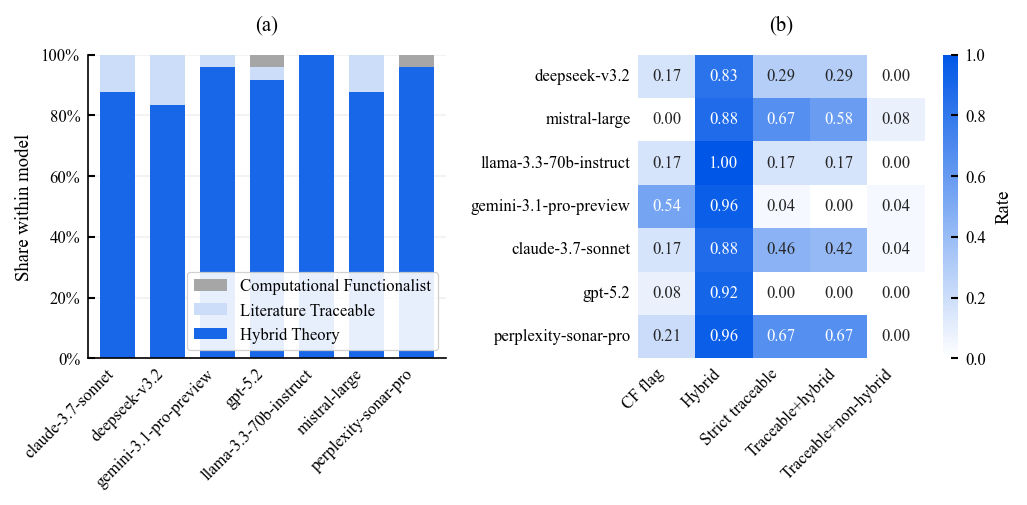

Saved: results/test3_theory_generation/category_distribution.png
Exclusive computational_functionalist count (category): 2
Non-exclusive computational functionalist count (is_cf): 32


In [45]:
# 1. Category + attribute views (exclusive vs non-exclusive)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1]})

category_order = ['genuinely_novel', 'hybrid_theory', 'computational_functionalist', 'literature_traceable', 'unclassified']
overall_counts = category_counts.reindex(category_order, fill_value=0)
exclusive_cf_count = int(overall_counts['computational_functionalist'])
nonexclusive_cf_count = int(results_df['is_cf'].sum())

# Left: exclusive categories by model (100% stacked)
ax = axes[0]
model_cat_counts = results_df.groupby(['model', 'category']).size().unstack(fill_value=0).reindex(columns=category_order, fill_value=0)

# Keep only categories that actually appear, then order by greatest overall share (bottom to top).
present_categories = [cat for cat in category_order if model_cat_counts[cat].sum() > 0]
if present_categories:
    stack_order = overall_counts.reindex(present_categories).sort_values(ascending=False).index.tolist()
else:
    stack_order = []

model_cat_counts = model_cat_counts.reindex(columns=stack_order, fill_value=0)
model_cat_pct = model_cat_counts.div(model_cat_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# Legend labels follow the same filtered/sorted categories.
legend_label_map = {
    'genuinely_novel': 'Genuinely Novel',
    'hybrid_theory': 'Hybrid Theory',
    'computational_functionalist': 'Computational Functionalist',
    'literature_traceable': 'Literature Traceable',
    'unclassified': 'Unclassified',
}
plot_columns = [legend_label_map[c] for c in stack_order]
plot_df = model_cat_pct.rename(columns=legend_label_map).reindex(columns=plot_columns, fill_value=0)

# Lighter stacked-bar colors aligned with project colormap style, with CF fixed to gray.
non_cf_categories = [c for c in stack_order if c != 'computational_functionalist']
non_cf_blues = [WHITE_SKY_CMAP(x) for x in np.linspace(0.90, 0.20, num=len(non_cf_categories))] if non_cf_categories else []
non_cf_color_map = dict(zip(non_cf_categories, non_cf_blues))
cf_gray = SKY_WHITE_GRAY_CMAP(0.85)
stack_colors = [cf_gray if c == 'computational_functionalist' else non_cf_color_map[c] for c in stack_order]

plot_df.plot(kind='bar', stacked=True, ax=ax, color=stack_colors, width=0.7)

ax.set_ylabel('Share within model')
ax.set_xlabel('')
ax.set_title('(a)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.3)

# Explicit legend order: top-to-bottom corresponds to top-to-bottom stack segments.
handles, labels = ax.get_legend_handles_labels()
handle_by_label = {lbl: h for h, lbl in zip(handles, labels)}
legend_labels = list(reversed(plot_columns))
legend_handles = [handle_by_label[lbl] for lbl in legend_labels if lbl in handle_by_label]
ax.legend(legend_handles, legend_labels, title='', loc='lower right', frameon=True, framealpha=0.9)

plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Right: non-exclusive attribute prevalence heatmap
ax = axes[1]
attr_cols = ['is_cf', 'is_hybrid', 'is_traceable', 'traceable_hybrid', 'traceable_non_hybrid']
attr_labels = ['CF flag', 'Hybrid', 'Strict traceable', 'Traceable+hybrid', 'Traceable+non-hybrid']
attr_rates = results_df.groupby('model')[attr_cols].mean().reindex(results_df['model'].drop_duplicates())

sns.heatmap(attr_rates, ax=ax, 
            cmap=WHITE_SKY_CMAP, 
            vmin=0, vmax=1, 
            annot=True, fmt='.2f',
            annot_kws={'size': 8},
            cbar_kws={'label': 'Rate'})
ax.set_title('(b)')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(attr_labels, rotation=45, ha='right')
ax.tick_params(left=False, bottom=False)
plt.tight_layout()


plt.savefig(output_dir / 'category_distribution.png', bbox_inches='tight')
plt.show()
print(f'Saved: {output_dir / "category_distribution.png"}')
print(f'Exclusive computational_functionalist count (category): {exclusive_cf_count}')
print(f'Non-exclusive computational functionalist count (is_cf): {nonexclusive_cf_count}')

Figure caption: (a) model-wise distribution of exclusive final categories as normalized stacked shares; (b) non-exclusive attribute prevalence rates by model for CF, hybrid, and traceability-related flags.

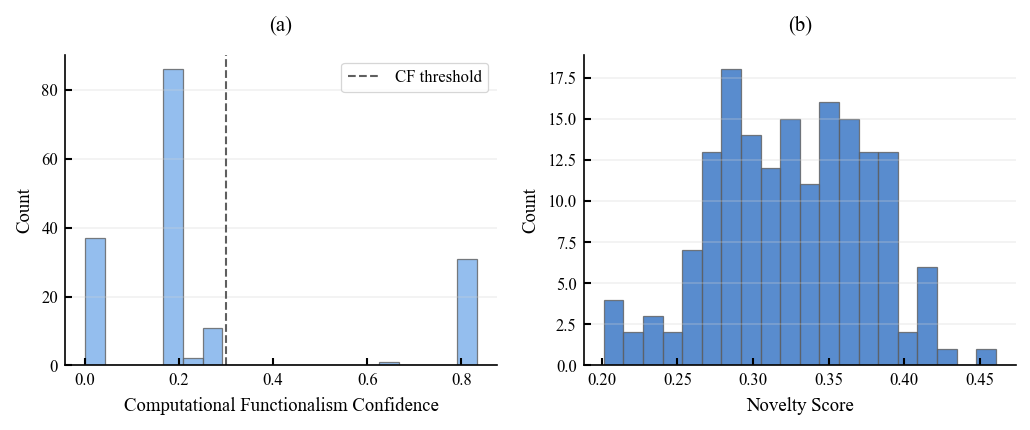

Saved: results/test3_theory_generation/score_distributions.png


In [37]:
# 2. CF confidence and novelty scores
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
# CF confidence distribution
ax = axes[0]
ax.hist(results_df['cf_confidence'], bins=20, edgecolor=THRESHOLD_COLOR, alpha=0.8, color=SIMILARITY_HIST_COLOR)
ax.axvline(0.3, color=THRESHOLD_COLOR, linestyle='--', linewidth=1, label='CF threshold')
ax.set_xlabel('Computational Functionalism Confidence')
ax.set_ylabel('Count')
ax.set_title('(a)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
# Novelty score distribution
ax = axes[1]
ax.hist(results_df['novelty_score'], bins=20, edgecolor=THRESHOLD_COLOR, alpha=0.8, color=BLUE_GRAY_RAMP[1])
ax.set_xlabel('Novelty Score')
ax.set_ylabel('Count')
ax.set_title('(b)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'score_distributions.png', bbox_inches='tight')
plt.show()
print(f'Saved: {output_dir / "score_distributions.png"}')

Figure caption: (a) distribution of computational functionalism confidence scores with threshold reference; (b) distribution of novelty scores across generated theories.

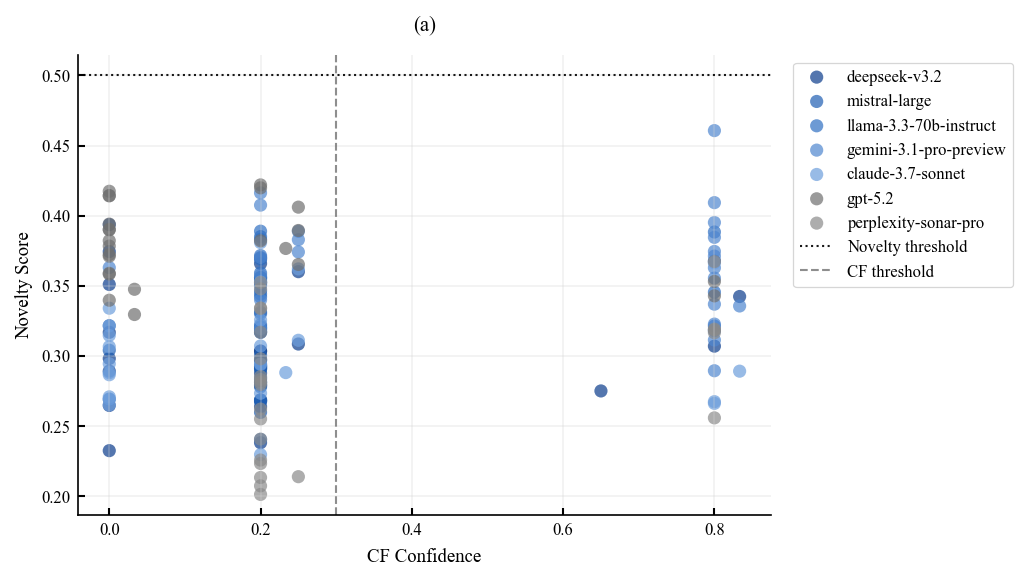

Saved: results/test3_theory_generation/cf_vs_novelty.png


In [50]:
# 3. Scatter: CF confidence vs novelty
fig, ax = plt.subplots(figsize=(7, 4))

model_order = results_df['model'].drop_duplicates().tolist()
model_color_map = {m: MODEL_VISIBLE_COLORS[i % len(MODEL_VISIBLE_COLORS)] for i, m in enumerate(model_order)}

for model in model_order:
    model_df = results_df[results_df['model'] == model]
    ax.scatter(model_df['cf_confidence'], 
               model_df['novelty_score'], 
               label=model, 
               alpha=0.7, 
               s=40, 
               color=model_color_map[model], edgecolors='none'
              )
ax.axhline(0.5, color='black', linestyle=':', alpha=0.9, label='Novelty threshold')
ax.axvline(0.3, color=THRESHOLD_COLOR, linestyle='--', alpha=0.7, label='CF threshold')
ax.set_xlabel('CF Confidence')
ax.set_ylabel('Novelty Score')
ax.set_title('(a)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'cf_vs_novelty.png', bbox_inches='tight')
plt.show()
print(f'Saved: {output_dir / "cf_vs_novelty.png"}')

Figure caption: (a) scatter relationship between computational functionalism confidence and novelty score, with reference thresholds marking category decision boundaries.

**Note on CF confidence distribution**

The `cf_confidence` score is a weighted sum of binary (True/False) keyword-presence features — it is not a continuous measurement. Because each component yields only 0 or its fixed weight (0.35, 0.25, 0.20, 0.10, 0.10), the score can only take a small number of discrete values, producing the fragmented, spike-like histogram rather than a smooth distribution. The score is used for visualization purposes only and is not used as a classification threshold.

**Why few instances in the 0.3–0.6 range:** 

This is a structural artifact of correlated binary features. The most common path to `is_functionalist = True` requires both `information_processing` AND `emergence_from_computation` to be True simultaneously — but those two features also contribute directly to `cf_confidence` (+0.25 and +0.20 respectively). Combined with the `is_functionalist` term (+0.35), a theory triggering the main path immediately accumulates `0.35 + 0.25 + 0.20 = 0.80`, skipping the 0.3–0.6 range entirely. Theories in that gap would require `is_functionalist = True` via an alternative trigger (`strong_score ≥ 2` or `quantum_as_mechanism`) *without* `information_processing` and `emergence_from_computation` also being True — a rarely occurring combination.

The result is two natural clusters with a near-empty middle band:

| Cluster | Condition | Typical score |
|---|---|---|
| Low (< 0.30) | `is_functionalist = False` | 0–0.25 |
| **Gap (0.3–0.6)** | `is_functionalist = True` via rare alternative path only | ~0.35–0.45 |
| High (> 0.60) | `is_functionalist = True` via main path | 0.80+ |

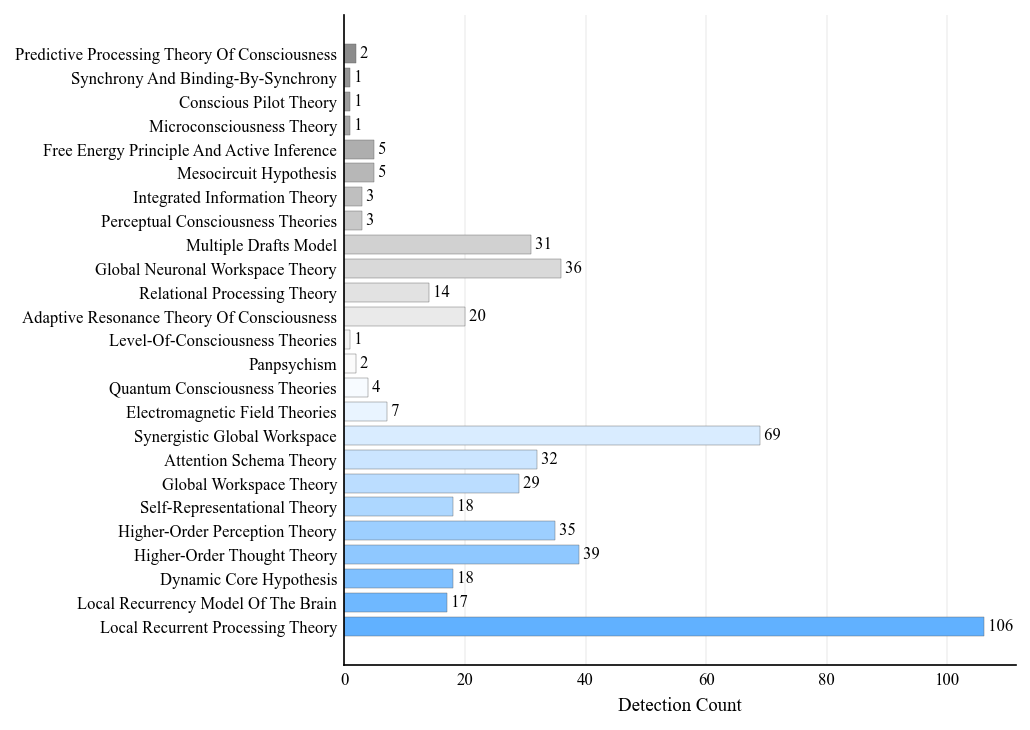

Saved: results/test3_theory_generation/detected_theories.png


In [56]:
# 4. Component theory detection
fig, ax = plt.subplots(figsize=(7, 5))

all_detected = []

for theories_str in results_df['detected_theories']:
    if theories_str:
        all_detected.extend(theories_str.split(','))

if all_detected:
    theory_counts = Counter(all_detected)
    theories = list(theory_counts.keys())
    counts = list(theory_counts.values())
    bar_colors = [SKY_WHITE_GRAY_CMAP(x) for x in np.linspace(0.15, 0.95, len(theories))]
    bars = ax.barh(range(len(theories)), 
                   counts, color=bar_colors, 
                   edgecolor=THRESHOLD_COLOR, 
                   linewidth=0.2
                   )
    ax.set_yticks(range(len(theories)))
    ax.set_yticklabels([t.replace('_', ' ').title() for t in theories])
    ax.set_xlabel('Detection Count')
    ax.set_title('')
    ax.tick_params(left=False, bottom=False)
    ax.set_axisbelow(True)
    ax.grid(axis='x', alpha=0.3)
    for bar, count in zip(bars, counts):
        ax.text(count, 
                bar.get_y() + bar.get_height() / 2.0, f' {int(count)}', 
                ha='left', va='center', 
                color=TEXT_COLOR,
                fontsize=8
                )
else:
    ax.text(0.5, 0.5, 'No theories detected', 
            ha='center', va='center', 
            transform=ax.transAxes, 
            color=TEXT_COLOR)

plt.tight_layout()
plt.savefig(output_dir / 'detected_theories.png', bbox_inches='tight')
plt.show()
print(f'Saved: {output_dir / "detected_theories.png"}')

Figure caption: (a) frequency of detected known-theory components among generated outputs, indicating which established frameworks are most often recovered.

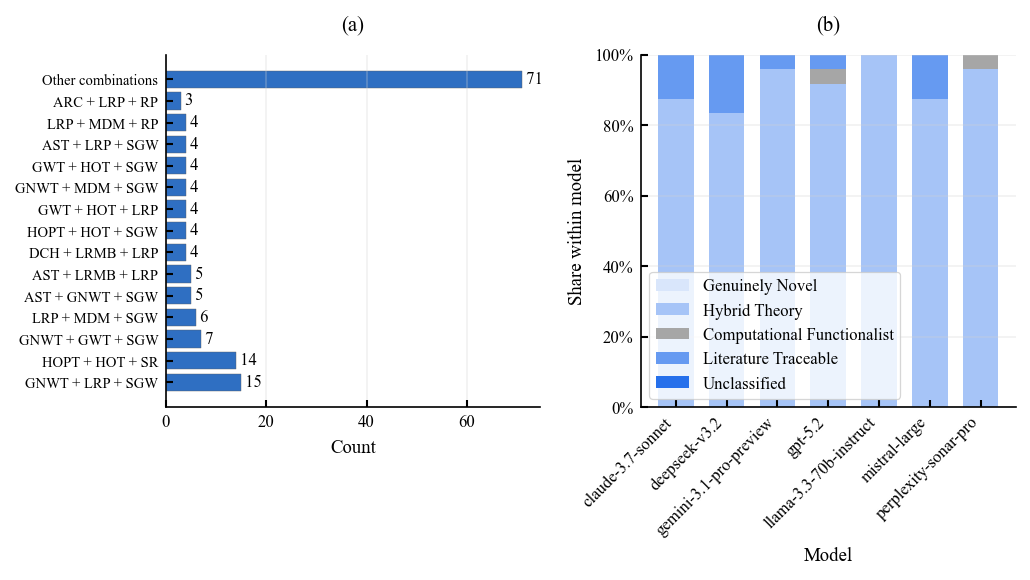

Saved: results/test3_theory_generation/hybrid_and_nonhierarchical_categories.png


In [55]:
# 5. Hybrid-theory internals + non-hierarchical category prevalence
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Left: explicit component combinations inside hybrid_theory
ax = axes[0]
hybrid_df = results_df[results_df['category'] == 'hybrid_theory'].copy()

if not hybrid_df.empty:
    def parse_detected_set(s):
        if not isinstance(s, str) or not s.strip():
            return frozenset()
        return frozenset(x.strip() for x in s.split(',') if x.strip())

    def acronym_from_theory_name(name: str) -> str:
        normalized = str(name).strip().lower().replace('-', ' ').replace('_', ' ')
        normalized = ' '.join(normalized.split())

        manual_map = {
            'global neuronal workspace theory': 'GNWT',
            'global workspace theory': 'GWT',
            'higher order thought': 'HOT',
            'higher order perception theory': 'HOPT',
            'integrated information theory': 'IIT',
            'attention schema theory': 'AST',
            'local recurrent processing': 'LRP',
            'dynamic core hypothesis': 'DCH',
            'adaptive resonance theory': 'ART',
            'synergistic theory': 'ST',
            'computational functionalism': 'CF',
        }
        if normalized in manual_map:
            return manual_map[normalized]

        words = [w for w in normalized.split() if w]
        stop = {'theory', 'of', 'and', 'the'}
        letters = ''.join(w[0].upper() for w in words if w not in stop)
        return letters if letters else normalized[:4].upper()

    combo_series = hybrid_df['detected_theories'].apply(parse_detected_set)
    combo_counts = combo_series.value_counts()

    # Keep only the most frequent combinations and collapse the rest.
    max_rows = 15
    if len(combo_counts) > max_rows:
        top_counts = combo_counts.head(max_rows - 1)
        other_count = int(combo_counts.iloc[max_rows - 1 :].sum())
        combo_counts = pd.concat([top_counts, pd.Series({'other_combinations': other_count})])

    combo_labels = []
    combo_values = []
    for combo, cnt in combo_counts.items():
        if combo == 'other_combinations':
            label = 'Other combinations'
        elif len(combo) == 0:
            label = 'None'
        else:
            label = ' + '.join(sorted(acronym_from_theory_name(t) for t in combo))
        combo_labels.append(label)
        combo_values.append(cnt)

    y_pos = np.arange(len(combo_labels))
    bars = ax.barh(y_pos, combo_values, color=BLUE_GRAY_RAMP[1], edgecolor=THRESHOLD_COLOR, linewidth=0.2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(combo_labels, fontsize=7)
    ax.set_xlabel('Count')
    ax.set_title('(a)')
    ax.grid(axis='x', alpha=0.3)

    for bar, val in zip(bars, combo_values):
        ax.text(val, bar.get_y() + bar.get_height()/2, f' {int(val)}', va='center', ha='left', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No hybrid_theory rows', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('(a)')

# Right: category prevalence by model under non-hierarchical counting
ax = axes[1]
model_cat = results_df.groupby(['model', 'category']).size().unstack(fill_value=0)
model_cat = model_cat.reindex(columns=category_order, fill_value=0)
model_cat_pct = model_cat.div(model_cat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

if 'category_colors' in globals():
    category_colors_local = category_colors
else:
    category_colors_local = {
        'genuinely_novel': WHITE_SKY_CMAP(0.15),
        'hybrid_theory': WHITE_SKY_CMAP(0.35),
        'computational_functionalist': SKY_WHITE_GRAY_CMAP(0.85),
        'literature_traceable': WHITE_SKY_CMAP(0.60),
        'unclassified': WHITE_SKY_CMAP(0.85),
    }

for i, cat in enumerate(category_order):
    ax.bar(model_cat_pct.index,
           model_cat_pct[cat],
           bottom=model_cat_pct[category_order[:i]].sum(axis=1),
           label=cat.replace('_', ' ').title(),
           color=category_colors_local.get(cat),
           width=0.7)
ax.set_ylabel('Share within model')
ax.set_xlabel('Model')
ax.set_title('(b)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(output_dir / 'hybrid_and_nonhierarchical_categories.png', bbox_inches='tight')
plt.show()
print(f'Saved: {output_dir / "hybrid_and_nonhierarchical_categories.png"}')

Figure caption: (a) internal component combinations within outputs classified as hybrid theory; (b) model-wise non-hierarchical prevalence of final theory categories as normalized stacked shares.

## 10. Representative Examples

In [41]:
print("\n" + "="*60)
print("REPRESENTATIVE EXAMPLES")
print("="*60)

for category in category_order:
    cat_examples = results_df[results_df['category'] == category]
    if len(cat_examples) > 0:
        print(f"\n{category.upper().replace('_', ' ')}:")
        print("-" * 60)
        
        # Show top 2 examples
        for i, (idx, row) in enumerate(cat_examples.head(2).iterrows()):
            print(f"\nExample {i+1} [{row['model']}]:")
            print(f"CF confidence: {row['cf_confidence']:.3f}")
            print(f"Novelty score: {row['novelty_score']:.3f}")
            print(f"Detected theories: {row['detected_theories'] if row['detected_theories'] else 'None'}")
            print(f"Components: {row['n_components']}")
            print(f"\nTheory excerpt (first 500 chars):")
            # Get original theory text
            theory_text = theories_data[idx]['theory_text']
            print(theory_text[:500] + "...")


REPRESENTATIVE EXAMPLES

HYBRID THEORY:
------------------------------------------------------------

Example 1 [deepseek-v3.2]:
CF confidence: 0.200
Novelty score: 0.370
Detected theories: Local Recurrent Processing Theory,Local Recurrency Model of the Brain,Dynamic Core Hypothesis
Components: 2

Theory excerpt (first 500 chars):
DRTC proposes that consciousness emerges from stable, self-sustaining resonance patterns within cortical tissue, termed the 'Consciousness Resonance Signature' (CRS). This signature forms through precise, recurrent interactions of neural populations firing in high-gamma (80-150 Hz) and epsilon (>200 Hz) frequency ranges. The multi-dimensional shape of this resonance—characterized by phase coherence, amplitude modulation depth, and spatial harmonic distribution across cortical layers—directly con...

Example 2 [mistral-large]:
CF confidence: 0.200
Novelty score: 0.291
Detected theories: Higher-Order Thought Theory,Higher-Order Perception Theory,Self-Represent

## 11. Export Results

In [42]:
# Save detailed results
results_df.to_csv(output_dir / 'detailed_results.csv', index=False)
print(f"Saved detailed results to {output_dir / 'detailed_results.csv'}")

# Save summary
summary = {
    'total_theories': len(results_df),
    'category_distribution': category_props.to_dict(),
    'cf_count': int(cf_count),
    'cf_proportion': float(cf_prop),
    'traceable_count': int(traceable),
    'traceable_proportion': float(traceable_prop),
    'traceable_non_hybrid_count': int(traceable_non_hybrid),
    'traceable_non_hybrid_proportion': float(traceable_non_hybrid_prop),
    'traceable_hybrid_count': int(traceable_hybrid),
    'traceable_hybrid_proportion': float(traceable_hybrid_prop),
    'hybrid_count': int(hybrid),
    'hybrid_proportion': float(hybrid_prop),
    'mean_cf_confidence': float(results_df['cf_confidence'].mean()),
    'mean_novelty_score': float(results_df['novelty_score'].mean()),
    'mean_similarity': float(results_df['max_similarity'].mean()),
    'models_analyzed': list(results_df['model'].unique())
}

with open(output_dir / 'summary_statistics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary statistics to {output_dir / 'summary_statistics.json'}")
print("\nTest 3 analysis complete!")

Saved detailed results to results/test3_theory_generation/detailed_results.csv
Saved summary statistics to results/test3_theory_generation/summary_statistics.json

Test 3 analysis complete!


## 12. Conclusions and Reporting Notes

This section notebook now reports two aligned category views:

1. **Strict category view** (`category_strict`): hard-rule hierarchy before fallback.
2. **Integrated final category view** (`category`): same hierarchy, with automatic reassignment of previously `unclassified` rows via nearest-threshold fallback.

**How integrated categorization works:**
- The strict hierarchy is computed first.
- If a row remains `unclassified`, it is reassigned to the nearest existing category using the fallback scoring rule.
- The reason is stored in `relabel_reason`.

**Interpretation constraints:**
- `is_traceable` remains the strict traceability attribute (`max_similarity >= 0.70`).
- A row can be `category = literature_traceable` after fallback while still having `is_traceable = False`.
- Therefore, strict traceability reporting should always use `is_traceable` (and `traceable_non_hybrid` / `traceable_hybrid`), not fallback category labels.

**Reporting rule:** `traceable_non_hybrid` is only the residual category of theories that are strict-traceable and not hybrid. It is not the total number of strict-traceable theories.

**Key Findings** (to report in Section 5.4):
- Proportion of computational-functionalist theories (with CI)
- Proportion of strictly traceable theories overall (with CI)
- Proportion of strictly traceable hybrid theories (with CI)
- Proportion of strictly traceable non-hybrid theories (with CI)
- Proportion of hybrid theories overall (with CI)
- Mean novelty scores
- Distribution of detected known theories
- Cross-model consistency results